# Project Name: Retail Sales

import libraries

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [14]:
data = pd.read_excel("Sample - Superstore (1).xlsx", sheet_name= 'Orders')

Display Data

In [19]:
data.head()

,Column1,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,flag,los,multi_condition
0,4962,CA-2016-156587,2016-03-07,2016-03-08,First Class,AB-10015,Aaron Bergman,Consumer,United States,Seattle,...,Furniture,Chairs,"Global Push Button Manager's Chair, Indigo",48.712,1,0.2,5.4801,Low,NaN,NaN
1,4963,CA-2016-156587,2016-03-07,2016-03-08,First Class,AB-10015,Aaron Bergman,Consumer,United States,Seattle,...,Office Supplies,Art,Newell 330,17.940,3,0.0,4.6644,Low,NaN,Review
2,4964,CA-2016-156587,2016-03-07,2016-03-08,First Class,AB-10015,Aaron Bergman,Consumer,United States,Seattle,...,Office Supplies,Storage,"Carina 42""Hx23 3/4""W Media Storage Unit",242.940,3,0.0,4.8588,Low,NaN,Review
3,8223,CA-2016-152905,2016-02-18,2016-02-24,Standard Class,AB-10015,Aaron Bergman,Consumer,United States,Arlington,...,Office Supplies,Storage,Akro Stacking Bins,12.624,2,0.2,-2.5248,Low,NaN,Review
4,8802,CA-2018-140935,2018-11-10,2018-11-12,First Class,AB-10015,Aaron Bergman,Consumer,United States,Oklahoma City,...,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,Low,NaN,Review


In [21]:
data.tail()

,Column1,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,flag,los,multi_condition
9989,3815,CA-2018-152471,2018-07-08,2018-07-08,Same Day,ZD-21925,Zuschuss Donatelli,Consumer,United States,Jacksonville,...,Technology,Phones,Jabra SPEAK 410 Multidevice Speakerphone,823.960,5,0.2,51.4975,High,NaN,False
9990,3816,CA-2018-152471,2018-07-08,2018-07-08,Same Day,ZD-21925,Zuschuss Donatelli,Consumer,United States,Jacksonville,...,Office Supplies,Paper,Xerox 1921,15.984,2,0.2,4.9950,Low,NaN,Review
9991,5898,CA-2018-167682,2018-04-03,2018-04-09,Standard Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,Richmond,...,Furniture,Furnishings,"Seth Thomas 13 1/2"" Wall Clock",71.120,4,0.0,22.0472,Low,NaN,Review
9992,5899,CA-2018-167682,2018-04-03,2018-04-09,Standard Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,Richmond,...,Technology,Phones,Plantronics Voyager Pro HD - Bluetooth Headset,259.960,4,0.0,124.7808,Low,NaN,Review
9993,8342,CA-2019-141481,2019-06-11,2019-06-14,First Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,Los Angeles,...,Office Supplies,Appliances,Kensington 6 Outlet Guardian Standard Surge Pr...,61.440,3,0.0,16.5888,Low,NaN,Review


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Column1          9994 non-null   int64         
 1   Order ID         9994 non-null   object        
 2   Order Date       9994 non-null   datetime64[ns]
 3   Ship Date        9994 non-null   datetime64[ns]
 4   Ship Mode        9994 non-null   object        
 5   Customer ID      9993 non-null   object        
 6   Customer Name    9994 non-null   object        
 7   Segment          9994 non-null   object        
 8   Country/Region   9994 non-null   object        
 9   City             9994 non-null   object        
 10  State            9994 non-null   object        
 11  Postal Code      9983 non-null   float64       
 12  Region           9994 non-null   object        
 13  Product ID       9994 non-null   object        
 14  Category         9994 non-null   object 

In [31]:
data.describe()

,Column1,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,los
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000,0.0
mean,4997.500000,2018-04-30 10:03:51.979187712,2018-05-04 09:03:29.645787392,55245.233297,229.858001,3.789574,0.156203,28.656896,NaN
min,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,NaN
25%,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,NaN
50%,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500,NaN
75%,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,NaN
max,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,NaN
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108,NaN


Data Cleaning

In [40]:
# Removing Unnecessary colums
data.drop(columns=['Column1'], inplace=True)

In [42]:
#Convert Dataset
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [44]:
# Check Missing Values
data.isnull().sum()

Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           1
Customer Name         0
Segment               0
Country/Region        0
City                  0
State                 0
Postal Code          11
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
flag                  0
los                9994
multi_condition       1
dtype: int64

In [46]:
# Remove Duplicates

data.drop_duplicates(inplace = True)

Feature Engineering

In [49]:
# Extract Yerar & Month

data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month

In [55]:
#Profit category
data['Profit_Status'] = data['Profit'].apply(lambda x:'Loss'if x < 0 else 'Profit')

 Exploratory Data Analysis

In [60]:
# Total Sales & Prifit
print('Total Sales', data['Sales'].sum())
print('Total Profit', data['Profit'].sum())

Total Sales 2296919.4883000003
Total Profit 286409.0804999999


In [62]:
# Sales by Categoty
Cat_Sales = data.groupby('Category')['Sales'].sum()
print(Cat_Sales)

Category
Furniture          741718.4233
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [66]:
# Prifit by Category
cat_profit = data.groupby('Category')['Profit'].sum()
print(cat_profit)

Category
Furniture           18463.3316
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [74]:
#  Region Wise Performance
region_profit = data.groupby('Region')['Profit'].sum()
print(region_profit)

Region
Central     39706.3625
East        91534.8388
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


In [80]:
# Top 10 Product By sales
top_product = data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_product)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


Visualization

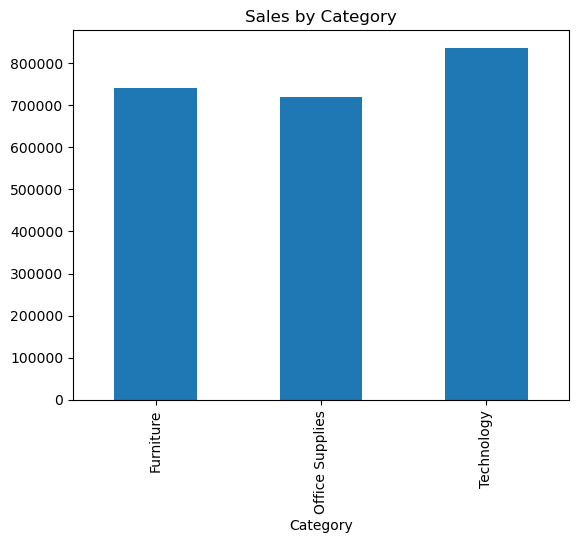

In [83]:
# sales by Category
Cat_Sales.plot(kind='bar', title="Sales by Category")
plt.show()

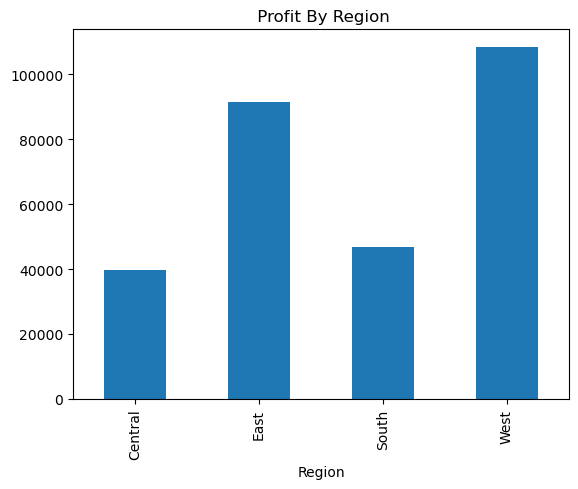

In [85]:
# Profit by Region
region_profit.plot(kind='bar', title= " Profit By Region")
plt.show()

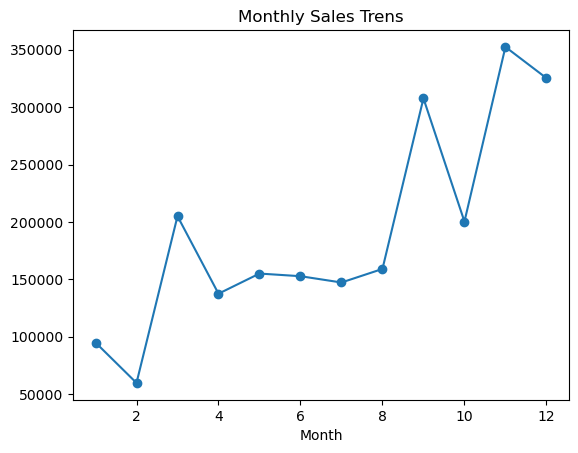

In [89]:
# Monthly Sales Trend
monthly_sales = data.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='line', marker='o', title="Monthly Sales Trens")
plt.show()

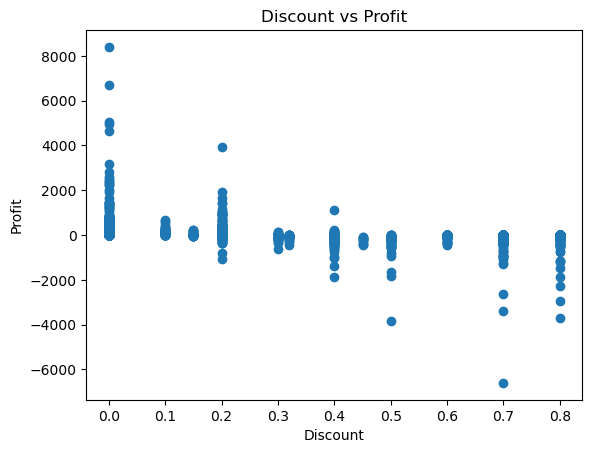

In [99]:
# Profit Vs Discount
plt.scatter(data['Discount'], data['Profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

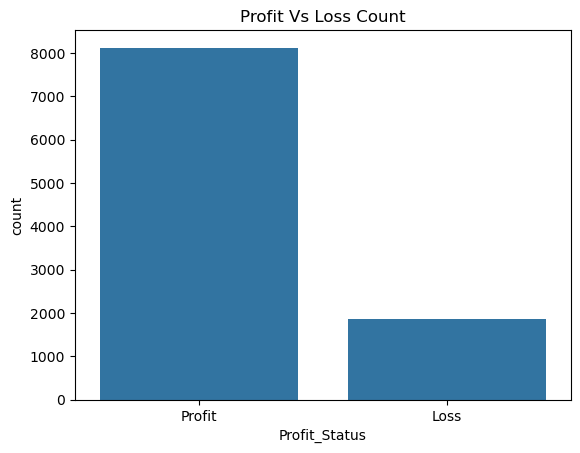

In [107]:
# Loss Vs Profit Count
sns.countplot(x='Profit_Status', data=data)
plt.title("Profit Vs Loss Count")
plt.show()